# Synthetic results

This notebook reports the completed primary DVFM-only synthetic experiment from `results/synthetic/`. It requires the run success marker and reads the raw prediction, latent-diagnostic, and run-manifest artifacts directly.

The main figure addresses four claims: individual frailty recovery, joint-survival recovery, Kendall's $\tau$ calibration, and predictive benefit over the $z=0$ ablation. Panel A omits $\tau=0$ because subject-level frailty recovery is undefined when the DGP has no shared-frailty signal. Panel B reports the paired z0-minus-z1 joint-survival ISE improvement. Panel C compares estimated conditional Kendall's $\tau$ with its target for DVFM-z1; the diagonal denotes perfect calibration, points below it indicate underestimation, and points above it indicate overestimation. It does not plot latent-$z$ values. Panel D reports the paired z0-minus-z1 Oracle IBS improvement. Values above zero in Panels B and D favor the shared-latent model.

In [1]:
from pathlib import Path
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, FuncFormatter, MultipleLocator

plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "large",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}",
    "savefig.bbox": "tight",
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "xtick.minor.size": 0,
    "ytick.minor.size": 0,
})

ROOT = Path.cwd()
if not (ROOT / "configs" / "synthetic.yaml").exists():
    ROOT = ROOT.parent
RESULT_DIR = ROOT / "results" / "synthetic"
FIGURE_DIR = ROOT / "paper" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def _primary_dvfm_rows(frame):
    out = frame[frame["model"].astype(str).str.lower().eq("dvfm")].copy()
    out = out[out["is_primary_checkpoint"].astype(str).str.lower().eq("true")]
    if "prediction_mode" in out:
        out = out[out["prediction_mode"].astype(str).str.lower().eq("prior")]
    return out

raw_path = RESULT_DIR / "results_raw.csv"
diagnostic_path = RESULT_DIR / "dvfm_diagnostics.csv"
manifest_path = RESULT_DIR / "run_manifest.csv"
required = [RESULT_DIR / "_SUCCESS", raw_path, diagnostic_path, manifest_path]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Synthetic run is incomplete; missing: " + ", ".join(missing))

manifest = pd.read_csv(manifest_path)
failures = manifest[~manifest["status"].eq("success")]
if not failures.empty:
    raise RuntimeError(f"Synthetic run contains {len(failures)} failed fits")
raw = _primary_dvfm_rows(pd.read_csv(raw_path))
diagnostics = _primary_dvfm_rows(pd.read_csv(diagnostic_path))
diagnostics = diagnostics[pd.to_numeric(diagnostics["latent_dim"], errors="coerce").eq(1)].copy()
if len(manifest) != 240 or len(raw) != 240 or len(diagnostics) != 360:
    raise RuntimeError(
        f"Unexpected artifact sizes: manifest={len(manifest)}, raw={len(raw)}, "
        f"z1 diagnostics={len(diagnostics)}"
    )
print(
    "COMPLETED SYNTHETIC RESULTS",
    f"| fits={len(manifest):,}, primary-prior rows={len(raw):,}, z1 diagnostics={len(diagnostics):,}",
)

COMPLETED SYNTHETIC RESULTS | fits=240, primary-prior rows=240, z1 diagnostics=360


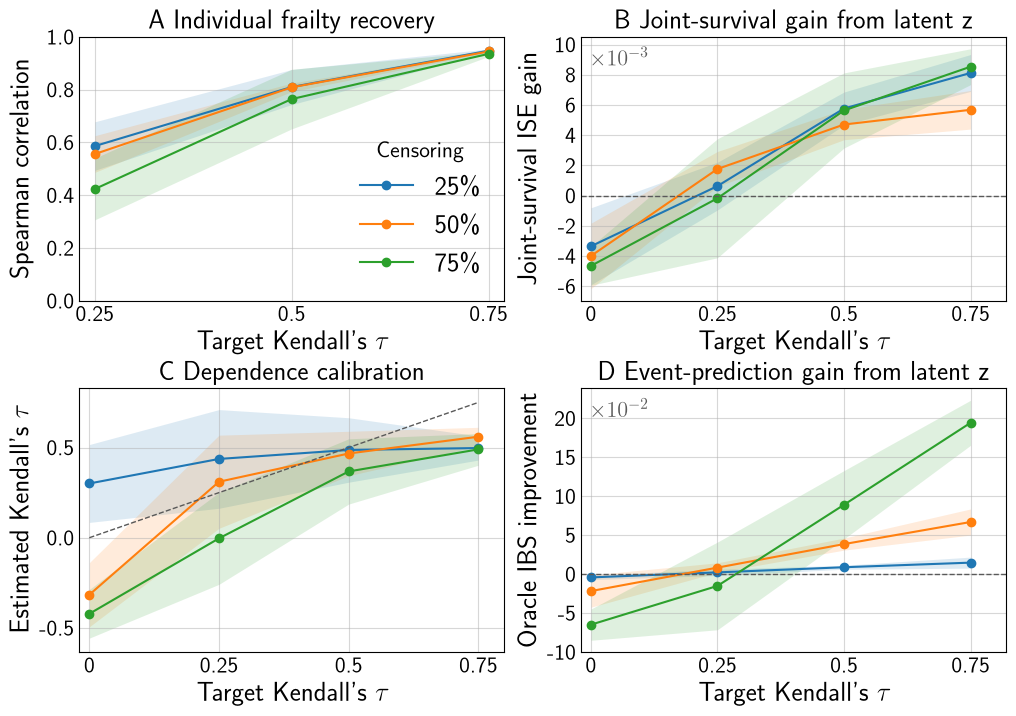

Wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_main.pdf


In [3]:
def mean_band(frame, groups, metric, sigma_level=1.0):
    out = frame.groupby(groups)[metric].agg(["mean", "std", "count"]).reset_index()
    out["error"] = sigma_level * out["std"].fillna(0)
    return out

z1 = raw[pd.to_numeric(raw["latent_dim"], errors="coerce").eq(1)].copy()
frailty_all = diagnostics[diagnostics["subgroup"].eq("all")].copy()
frailty_summary = mean_band(frailty_all, ["target_kendall_tau", "target_censoring_rate"], "frailty_spearman")
frailty_summary = frailty_summary[frailty_summary["target_kendall_tau"].gt(0)].copy()
tau_summary = mean_band(z1, ["target_kendall_tau", "target_censoring_rate"], "learned_conditional_kendall_tau")
joint_wide = raw.pivot_table(index=["repeat", "target_kendall_tau", "target_censoring_rate"], columns="latent_dim", values="oracle_joint_survival_ise").reset_index()
joint_wide["joint_ise_gain"] = joint_wide[0] - joint_wide[1]
joint_summary = mean_band(joint_wide, ["target_kendall_tau", "target_censoring_rate"], "joint_ise_gain")

ibs_wide = raw.pivot_table(index=["repeat", "target_kendall_tau", "target_censoring_rate"], columns="latent_dim", values="oracle_ibs").reset_index()
ibs_wide["oracle_ibs_gain"] = ibs_wide[0] - ibs_wide[1]
gain_summary = mean_band(ibs_wide, ["target_kendall_tau", "target_censoring_rate"], "oracle_ibs_gain")

fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.0), sharex=False, constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.02, hspace=0.02)
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = dict(zip((0.25, 0.50, 0.75), default_colors[:3]))
tau_ticks = np.array([0.0, 0.25, 0.5, 0.75])
tau_tick_labels = ["0", "0.25", "0.5", "0.75"]
frailty_taus = np.sort(frailty_summary["target_kendall_tau"].unique())
for censoring, part in frailty_summary.groupby("target_censoring_rate"):
    part = part.sort_values("target_kendall_tau")
    x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "error"))
    axes[0, 0].fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
    axes[0, 0].plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
axes[0, 0].set_xticks(frailty_taus, [f"{tau:g}" for tau in frailty_taus])
axes[0, 0].set(title=r"A  Individual frailty recovery", xlabel=r"Target Kendall's $\tau$", ylabel="Spearman correlation", xlim=(0.23, 0.77), ylim=(0, 1))
axes[0, 0].set_yticks(np.arange(0.0, 1.01, 0.2))
axes[0, 0].yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
axes[0, 0].legend(title="Censoring", loc="lower right", frameon=False)

for censoring, part in joint_summary.groupby("target_censoring_rate"):
    part = part.sort_values("target_kendall_tau")
    x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "error"))
    axes[0, 1].fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
    axes[0, 1].plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
axes[0, 1].axhline(0, color="0.35", linestyle="--", linewidth=1)
axes[0, 1].set(title="B  Joint-survival gain from latent z", xlabel=r"Target Kendall's $\tau$", ylabel="Joint-survival ISE gain", xlim=(-0.02, 0.82))
axes[0, 1].set_xticks(tau_ticks, tau_tick_labels)
axes[0, 1].yaxis.set_major_locator(MultipleLocator(0.002))
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value * 1e3:.0f}"))
axes[0, 1].text(0.02, 0.96, r"$\times 10^{-3}$", transform=axes[0, 1].transAxes, va="top", color="0.35")
#axes[0, 1].legend(title="Censoring", loc="lower right", frameon=False, bbox_to_anchor=(1.0, -0.04))

for censoring, part in tau_summary.groupby("target_censoring_rate"):
    part = part.sort_values("target_kendall_tau")
    x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "error"))
    axes[1, 0].fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
    axes[1, 0].plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
tau_low = min(0.0, float((tau_summary["mean"] - tau_summary["error"]).min()))
tau_high = max(0.75, float((tau_summary["mean"] + tau_summary["error"]).max()))
tau_pad = 0.06 * (tau_high - tau_low)
axes[1, 0].plot([0, 0.75], [0, 0.75], color="0.35", linestyle="--", linewidth=1, label="Perfect calibration")
axes[1, 0].set(title=r"C  Dependence calibration", xlabel=r"Target Kendall's $\tau$", ylabel=r"Estimated Kendall's $\tau$", xlim=(-0.02, 0.80), ylim=(tau_low - tau_pad, tau_high + tau_pad))
axes[1, 0].set_xticks(tau_ticks, tau_tick_labels)
axes[1, 0].yaxis.set_major_locator(MultipleLocator(0.5))
axes[1, 0].yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
#axes[1, 0].legend(title="Censoring", loc="lower right", frameon=False, bbox_to_anchor=(1.0, -0.04))

for censoring, part in gain_summary.groupby("target_censoring_rate"):
    part = part.sort_values("target_kendall_tau")
    x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "error"))
    axes[1, 1].fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
    axes[1, 1].plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
axes[1, 1].axhline(0, color="0.35", linestyle="--", linewidth=1)
axes[1, 1].set(title="D  Event-prediction gain from latent z", xlabel=r"Target Kendall's $\tau$", ylabel="Oracle IBS improvement", xlim=(-0.02, 0.82))
axes[1, 1].set_xticks(tau_ticks, tau_tick_labels)
axes[1, 1].yaxis.set_major_locator(MultipleLocator(0.05))
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value * 1e2:.0f}"))
axes[1, 1].text(0.02, 0.96, r"$\times 10^{-2}$", transform=axes[1, 1].transAxes, va="top", color="0.35")
#axes[1, 1].legend(title="Censoring", loc="lower right", frameon=False, bbox_to_anchor=(1.0, -0.04))
fig.align_ylabels(axes[:, 0])
fig.align_ylabels(axes[:, 1])

# Grid on all panels
for ax in axes.flat:
    ax.grid(True, alpha=0.5)

out = FIGURE_DIR / "synthetic_main.pdf"
fig.savefig(out)
plt.show()
print(f"Wrote {out}")